In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from etl.extract import extract


In [ ]:
data_path= r"C:\Users\melis\OneDrive\Masaüstü\ML PROJECT\banking_analytics_project\data\Bank_Customer_Churn_Prediction.csv"
df= extract(data_path)
df

raw data loaded: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


customer_id: Bir kimlik numarasıdır.
credit_score: Müşterinin kredi notu.
country: Müşterinin ülkesi (Örn: Fransa, İspanya, Almanya).
gender: Müşterinin cinsiyeti.
age: Müşterinin yaşı.
tenure: Müşterinin kaç yıldır bu banka ile çalıştığını gösterir.
balance: Müşterinin banka hesabındaki mevcut para miktarı.
products_number: Müşterinin bankadan kullandığı toplam ürün sayısı (Örn: Kredi kartı, mevduat hesabı, kredi, sigorta vb.).
credit_card: Müşterinin kredi kartı olup olmadığını gösterir.
active_member: Müşterinin aktif bir kullanıcı olup olmadığı.
estimated_salary: Müşterinin tahmini yıllık maaşı/geliri.
churn: Müşterinin bankayı terk edip etmediğini gösteren kritik sütundur.
        1: Müşteri bankadan ayrıldı (Churn oldu).
        0: Müşteri hala bankada kalmaya devam ediyor.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [29]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


C:\Users\melis\AppData\Local\Temp\ipykernel_13352\1573892991.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="churn", data=df, palette="Paired")


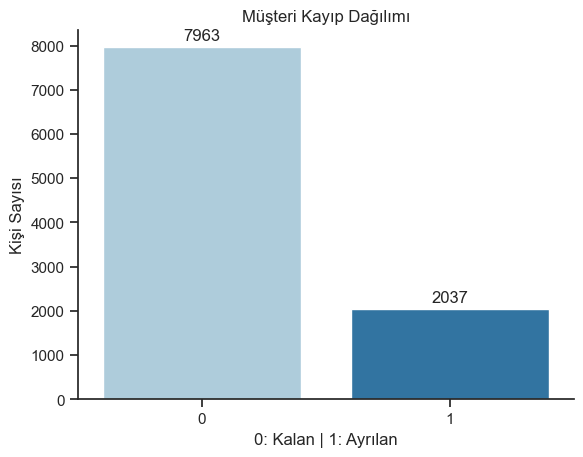

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x="churn", data=df, palette="Paired") 
ax.bar_label(ax.containers[0], padding=3)
ax.bar_label(ax.containers[1], padding=3)
plt.title("Müşteri Kayıp Dağılımı")
plt.xlabel("0: Kalan | 1: Ayrılan")
plt.ylabel("Kişi Sayısı")

plt.show()

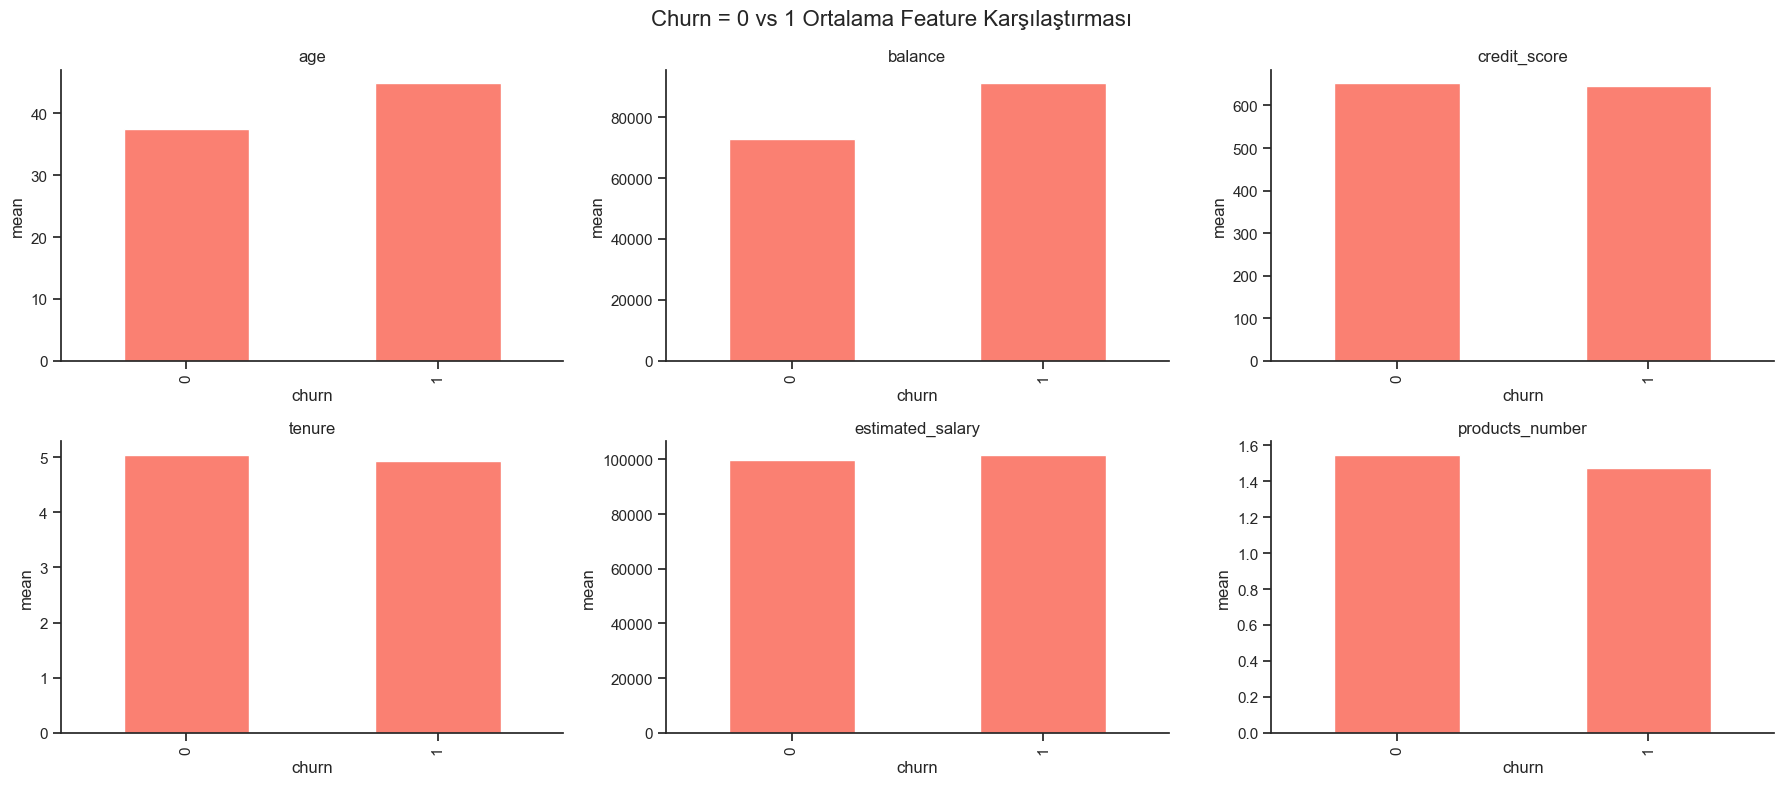

In [74]:
features = [
    "age",
    "balance",
    "credit_score",
    "tenure",
    "estimated_salary",
    "products_number",
]	
grouped = df.groupby("churn")[features].mean()
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for i, feature in enumerate(features):

    grouped[[feature]].plot(kind="bar",ax=axes[i], legend=False,color= "salmon")

    axes[i].set_title(feature)
    axes[i].set_xlabel("churn")
    axes[i].set_ylabel("mean")

plt.suptitle("Churn = 0 vs 1 Ortalama Feature Karşılaştırması", fontsize=16)
plt.tight_layout()
plt.show()


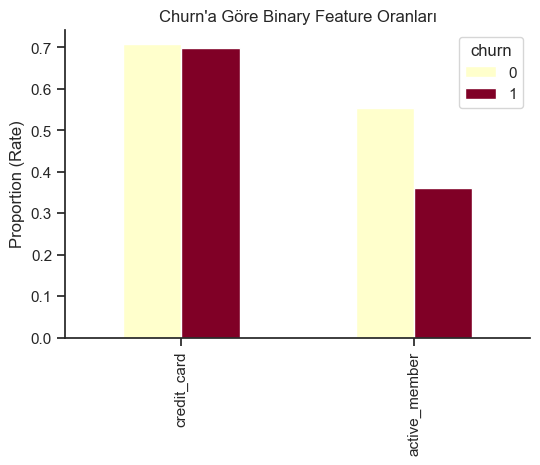

In [91]:
features_binary = ["credit_card", "active_member"]

grouped_bin = df.groupby("churn")[features_binary].mean()
grouped_bin.T.plot(kind="bar", figsize=(6,4), colormap="YlOrRd")


plt.ylabel("Proportion (Rate)")
plt.title("Churn'a Göre Binary Feature Oranları")
plt.show()


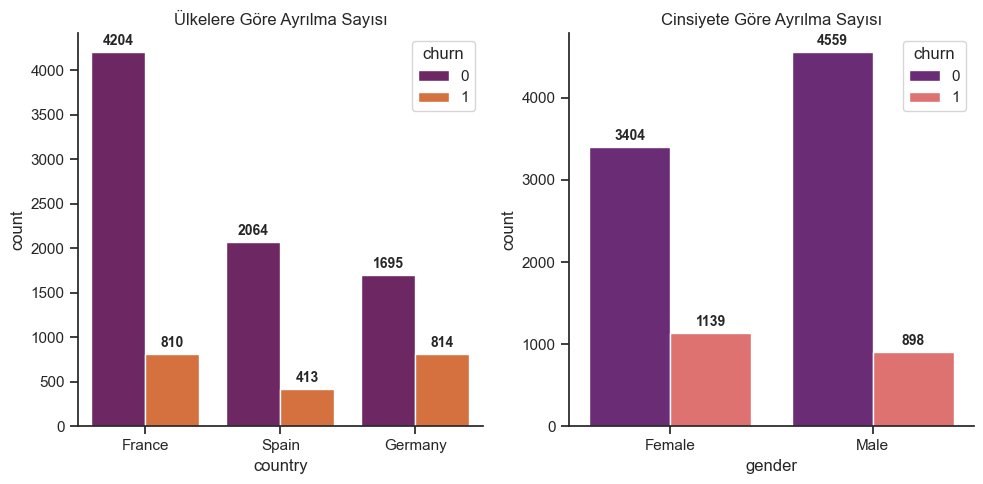

In [90]:
fig, ax = plt.subplots(1, 2,figsize=(10,5))
sns.countplot(x="country", hue="churn", data=df, ax=ax[0], palette="inferno")
ax[0].set_title("Ülkelere Göre Ayrılma Sayısı")
for container in ax[0].containers:
    ax[0].bar_label(container, padding=3, fontsize=10, fontweight='bold')

sns.countplot(x="gender", hue="churn", data=df, ax=ax[1], palette="magma")
ax[1].set_title("Cinsiyete Göre Ayrılma Sayısı")
for container in ax[1].containers:
    ax[1].bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

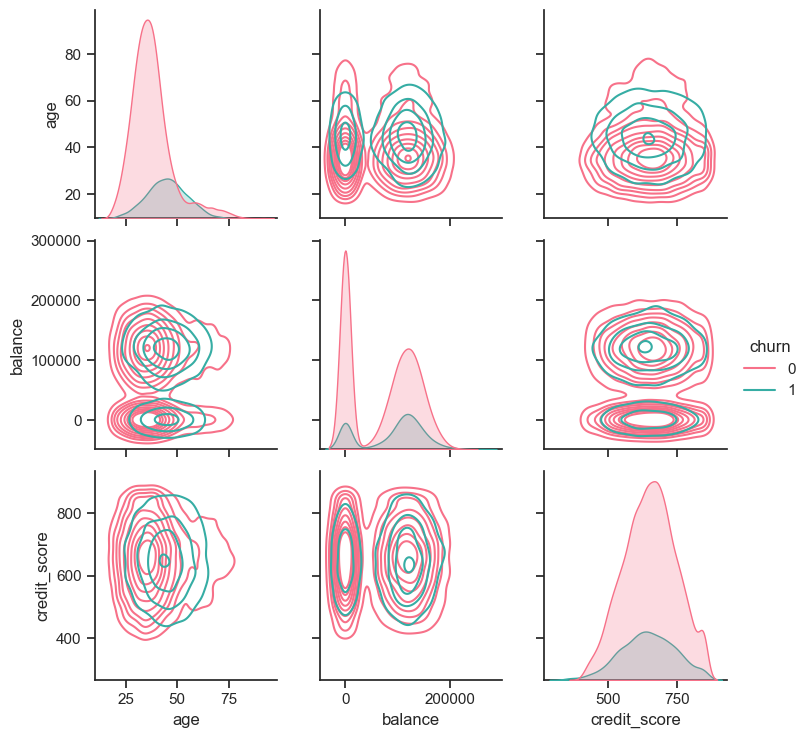

In [70]:
sns.pairplot(df[["age","balance","credit_score","churn"]],
             hue="churn", palette="husl",kind="kde")
plt.show()


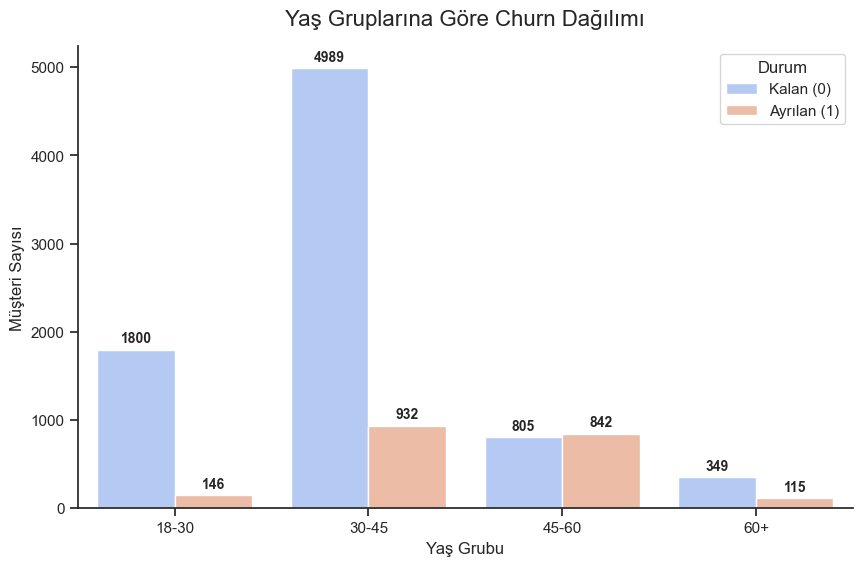

In [92]:
df["AgeGroup"] = pd.cut(df["age"],bins=[18, 30, 45, 60, 100], labels=["18-30", "30-45", "45-60", "60+"])
plt.figure(figsize=(10, 6))
ax = sns.countplot(x="AgeGroup", hue="churn", data=df, palette="coolwarm")

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.title("Yaş Gruplarına Göre Churn Dağılımı", fontsize=16, pad=15)
plt.xlabel("Yaş Grubu", fontsize=12)
plt.ylabel("Müşteri Sayısı", fontsize=12)
plt.legend(title="Durum", labels=["Kalan (0)", "Ayrılan (1)"])
plt.show()